In [1]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("data_NHANES")

BASE_COLUMN_MAP = {
    "DEMO": ["SEQN", "RIDAGEYR"],
    "BMX": ["SEQN", "BMXBMI", "BMXWAIST"],
    "BPX": ["SEQN", "BPXSY1", "BPXDI1"],
    "GLU": ["SEQN", "LBXGLU"],
    "GHB": ["SEQN", "LBXGH"],
    "BIOPRO": ["SEQN", "LBXSCR", "LBXSATSI", "LBXSASSI", "LBXSBU", "LBXSAL"],
    "HDL": ["SEQN", "LBDHDD"],
    "TRIGLY": ["SEQN", "LBXTR"],
    "TCHOL": ["SEQN", "LBXTC"]
}

CYCLE_SUFFIXES = ["D", "E", "F", "G", "H", "I", "J"]
COLUMN_MAP = {
    f"{base}_{suffix}": columns
    for base, columns in BASE_COLUMN_MAP.items()
    for suffix in CYCLE_SUFFIXES
}

def resolve_xpt_path(file_key: str) -> Path | None:
    primary_path = DATA_DIR / f"{file_key}.xpt"
    if primary_path.exists():
        return primary_path
    candidates = list(DATA_DIR.glob(f"{file_key}*.xpt"))
    if len(candidates) == 1:
        return candidates[0]
    return None

def load_xpt(file_key: str, columns: list[str]) -> pd.DataFrame:
    file_path = resolve_xpt_path(file_key)
    if file_path is None:
        print(f"[WARN] 파일 없음: {DATA_DIR / (file_key + '.xpt')}")
        return pd.DataFrame(columns=columns)
    df = pd.read_sas(file_path, format="xport")
    df.columns = df.columns.str.upper()
    requested = [c.upper() for c in columns]
    requested = list(dict.fromkeys(requested))

    available = [c for c in requested if c in df.columns]
    if len(available) != len(requested):
        missing = sorted(set(requested) - set(available))
        print(f"[WARN] 누락 컬럼({file_key}): {missing}")
    return df[available]

dataframes = {
    file_key: load_xpt(file_key, columns)
    for file_key, columns in COLUMN_MAP.items()
}

In [2]:
# 각 연도(알파벳)별로 SEQN 기준 병합 후 하나의 데이터프레임으로 결합

def get_cycle_key(file_key: str) -> str:
    return file_key.split("_")[-1]

merged_by_cycle: dict[str, pd.DataFrame] = {}
for file_key, df in dataframes.items():
    if df.empty:
        continue

    cycle = get_cycle_key(file_key)
    if cycle not in merged_by_cycle:
        merged_by_cycle[cycle] = df.copy()
        continue
    merged_by_cycle[cycle] = merged_by_cycle[cycle].merge(df, on="SEQN", how="left")

if not merged_by_cycle:
    raise ValueError("병합할 데이터가 없습니다.")

merged_frames = []
for cycle, df in merged_by_cycle.items():
    df = df.copy()
    df["NHANES_CYCLE"] = cycle
    merged_frames.append(df)

merged_df = pd.concat(merged_frames, ignore_index=True, sort=False)

# 1) 대상 인구: 만 20세 이상과 만 75세 미만 성인만 유지
merged_df = merged_df[(merged_df["RIDAGEYR"] >= 20) & (merged_df["RIDAGEYR"] < 70)]

selected_features = [
    "RIDAGEYR",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGLU",
    "LBXGH",
    "LBXSATSI",
    "LBXSASSI",
    "LBXSCR",
    "LBXSBU",
    "LBXSAL",
    "LBDHDD",
    "LBXTR",
    "LBXTC"
]

available_features = [c for c in selected_features if c in merged_df.columns]
missing_features = sorted(set(selected_features) - set(available_features))
if missing_features:
    print(f"[WARN] 누락된 특성: {missing_features}")

X_raw = merged_df[available_features].copy()
print(f"선택된 특성 수: {len(available_features)}")
print(f"클러스터링 입력 shape: {X_raw.shape}")

선택된 특성 수: 15
클러스터링 입력 shape: (32818, 15)


In [3]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32818 entries, 4 to 70189
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SEQN          32818 non-null  float64
 1   RIDAGEYR      32818 non-null  float64
 2   BMXBMI        31337 non-null  float64
 3   BMXWAIST      30186 non-null  float64
 4   BPXSY1        28879 non-null  float64
 5   BPXDI1        28879 non-null  float64
 6   LBXGLU        14479 non-null  float64
 7   LBXGH         30085 non-null  float64
 8   LBXSCR        29707 non-null  float64
 9   LBXSATSI      29653 non-null  float64
 10  LBXSASSI      29638 non-null  float64
 11  LBXSBU        29705 non-null  float64
 12  LBXSAL        29710 non-null  float64
 13  LBDHDD        29798 non-null  float64
 14  LBXTR         14212 non-null  float64
 15  LBXTC         29798 non-null  float64
 16  NHANES_CYCLE  32818 non-null  object 
dtypes: float64(16), object(1)
memory usage: 4.5+ MB


In [4]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd

if not available_features:
    raise ValueError("사용 가능한 특성이 없습니다. 컬럼 매핑을 확인하세요.")

# --- 기존 학습/검증 분할 로직 (요청에 따라 주석 처리) ---
# from sklearn.model_selection import train_test_split
# X_train_raw, X_test_raw = train_test_split(
#     X_raw,
#     test_size=0.2,
#     random_state=42,
# )

# 전체 데이터 사용
X_all_raw = X_raw.copy()

imputer = IterativeImputer(random_state=42)
X_all_imputed = pd.DataFrame(
    imputer.fit_transform(X_all_raw),
    columns=available_features,
    index=X_all_raw.index,
)

cluster_scaler = StandardScaler()
X_all_scaled = cluster_scaler.fit_transform(X_all_imputed)
X_scaled_df = pd.DataFrame(
    X_all_scaled,
    columns=available_features,
    index=X_all_raw.index,
)

N_CLUSTERS = 3
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(X_scaled_df)

train_clusters = pd.Series(cluster_labels, index=X_all_raw.index, name="Cluster")
age_by_cluster = (
    merged_df.loc[X_all_raw.index, ["RIDAGEYR"]]
    .join(train_clusters)
    .groupby("Cluster")["RIDAGEYR"]
    .mean()
    .sort_values()
)
ordered_labels = age_by_cluster.index.tolist()
label_map = {old: new for new, old in enumerate(ordered_labels, start=1)}

# 나이순으로 라벨 재정의: 가장 어린 클러스터=1, 가장 나이가 많은 클러스터=3
y = pd.Series(cluster_labels, index=X_all_raw.index).map(label_map)

merged_df["Cluster"] = y

target_col = "Cluster"
X = X_scaled_df

print(f"클러스터 분포(전체): {y.value_counts().sort_index().to_dict()}")

클러스터 분포(전체): {1: 15562, 2: 15871, 3: 1385}


In [5]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled_df, merged_df["Cluster"])
print(f"실루엣 점수: {sil_score:.4f}")

실루엣 점수: 0.1479


In [6]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report, confusion_matrix, recall_score
# from sklearn.model_selection import StratifiedKFold, cross_val_score
# from sklearn.utils.class_weight import compute_class_weight
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# import numpy as np

# classes = np.unique(y_train)
# num_classes = len(classes)
# class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
# class_weight_map = {cls: weight for cls, weight in zip(classes, class_weights)}
# sample_weight = np.array([class_weight_map[cls] for cls in y_train])

# models = {
#     "LogisticRegression": LogisticRegression(
#         max_iter=2000,
#         random_state=42,
#         class_weight=class_weight_map,
#     ),
#     "RandomForest": RandomForestClassifier(
#         n_estimators=300,
#         random_state=42,
#         class_weight=class_weight_map,
#     ),
#     "LightGBM": LGBMClassifier(
#         objective="multiclass",
#         num_class=num_classes,
#         random_state=42,
#         verbose=-1,
#         class_weight=class_weight_map,
#     ),
#     "XGBoost": XGBClassifier(
#         objective="multi:softprob",
#         num_class=num_classes,
#         eval_metric="mlogloss",
#         random_state=42,
#     ),
# }

# def fit_and_predict(model_name, model):
#     if model_name == "XGBoost":
#         y_train_fit = y_train - 1
#         model.fit(X_train_scaled_df, y_train_fit, sample_weight=sample_weight)
#         train_pred = model.predict(X_train_scaled_df) + 1
#         test_pred = model.predict(X_test_scaled_df) + 1
#     else:
#         model.fit(X_train_scaled_df, y_train)
#         train_pred = model.predict(X_train_scaled_df)
#         test_pred = model.predict(X_test_scaled_df)
#     train_recall = recall_score(y_train, train_pred, average="macro")
#     test_recall = recall_score(y_test, test_pred, average="macro")
#     return train_recall, test_recall, train_pred, test_pred

# def cross_val_macro_recall(model_name, model):
#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     if model_name == "XGBoost":
#         scores = cross_val_score(
#             model,
#             X_train_scaled_df,
#             y_train - 1,
#             cv=cv,
#             scoring="recall_macro",
#         )
#     else:
#         scores = cross_val_score(
#             model,
#             X_train_scaled_df,
#             y_train,
#             cv=cv,
#             scoring="recall_macro",
#         )
#     return scores.mean(), scores.std()

# results_train = {}
# results_test = {}
# results_cv = {}
# best_name = None
# best_recall = -1
# best_model = None
# best_train_pred = None
# best_test_pred = None

# for name, model in models.items():
#     cv_mean, cv_std = cross_val_macro_recall(name, model)
#     results_cv[name] = (cv_mean, cv_std)

#     train_recall, test_recall, train_pred, test_pred = fit_and_predict(name, model)
#     results_train[name] = train_recall
#     results_test[name] = test_recall

#     if test_recall > best_recall:
#         best_recall = test_recall
#         best_name = name
#         best_model = model
#         best_train_pred = train_pred
#         best_test_pred = test_pred

# print("모델별 Recall (macro) - CV 평균/표준편차:", results_cv)
# print("모델별 Recall (macro) - Train:", results_train)
# print("모델별 Recall (macro) - Test:", results_test)
# print(f"\n최고 Recall 모델(Test 기준): {best_name} ({best_recall:.4f})")

# print("\n=== Train 분류 리포트 ===")
# print(classification_report(y_train, best_train_pred))
# print("=== Train 혼동 행렬 ===")
# print(confusion_matrix(y_train, best_train_pred))

# print("\n=== Test 분류 리포트 ===")
# print(classification_report(y_test, best_test_pred))
# print("=== Test 혼동 행렬 ===")
# print(confusion_matrix(y_test, best_test_pred))

# 부록

### Hopkins Statistic / VAT 시각화 

Hopkins Statistic: 0.9679
결과: 데이터에 강력한 클러스터링 구조가 존재할 가능성이 높습니다.


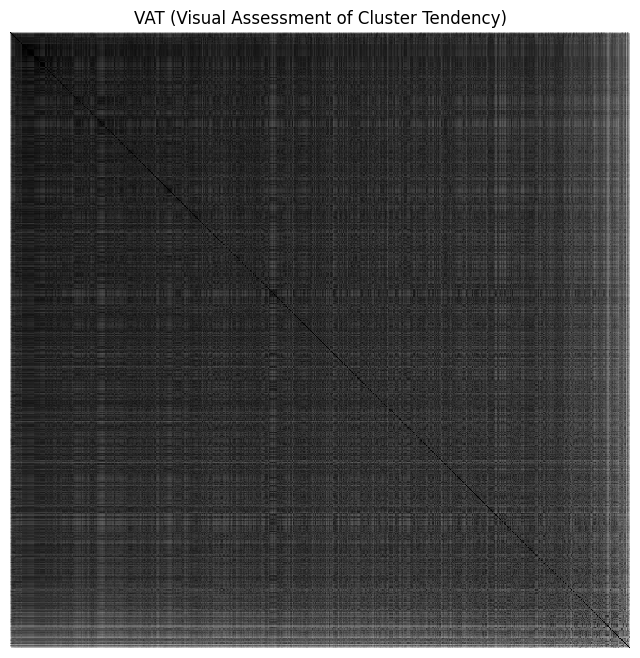

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from sklearn.utils import resample

def hopkins_statistic(X, n_samples=None):
    """
    Hopkins Statistic (H) 계산
    H가 0.5 근처면 무작위 분포, 1.0에 가까우면 높은 클러스터링 경향을 의미합니다.
    """
    X = np.asarray(X)
    n, d = X.shape
    
    if n_samples is None:
        n_samples = min(int(0.1 * n), 500) # 데이터가 크면 최대 500개 샘플링
    
    # 1. 데이터 범위 내에서 랜덤하게 생성된 포인트 (U)
    random_points = np.random.uniform(X.min(axis=0), X.max(axis=0), (n_samples, d))
    
    # 2. 원본 데이터에서 랜덤하게 추출된 실제 포인트 (W)
    real_samples = resample(X, n_samples=n_samples, replace=False, random_state=42)
    
    # Nearest Neighbors 모델
    neigh = NearestNeighbors(n_neighbors=2)
    neigh.fit(X)
    
    # u_i: 랜덤 포인트에서 원본 데이터까지의 거리
    u_distances, _ = neigh.kneighbors(random_points, n_neighbors=1)
    u_sum = np.sum(u_distances)
    
    # w_i: 실제 포인트에서 가장 가까운 (자신이 아닌) 포인트까지의 거리
    w_distances, _ = neigh.kneighbors(real_samples, n_neighbors=2)
    w_sum = np.sum(w_distances[:, 1])
    
    h = u_sum / (u_sum + w_sum)
    return h

def plot_vat(X):
    """
    VAT (Visual Assessment of Cluster Tendency) 시각화
    대각선을 따라 어두운 블록(사각형)이 뚜렷할수록 클러스터 구조가 존재함을 의미합니다.
    """
    # 연산 속도를 위해 샘플링 (1000개 수준이 적당)
    if X.shape[0] > 1000:
        X_sample = resample(X, n_samples=1000, replace=False, random_state=42)
    else:
        X_sample = X
        
    # 1. pairwise distance matrix 계산
    dist_matrix = pairwise_distances(X_sample, metric='euclidean')
    
    # 2. VAT 알고리즘 (MST 기반 재정렬)
    n = dist_matrix.shape[0]
    P = np.zeros(n, dtype=int)
    V = np.arange(n)
    ordered_indices = []
    
    # 첫 번째 인덱스 (가장 거리가 먼 쌍 중 하나)
    start_idx = np.unravel_index(np.argmax(dist_matrix), dist_matrix.shape)[0]
    ordered_indices.append(start_idx)
    V = np.delete(V, np.where(V == start_idx))
    
    # 순차적으로 가장 가까운 점 추가
    while len(V) > 0:
        dists = dist_matrix[ordered_indices][:, V]
        min_idx = np.unravel_index(np.argmin(dists), dists.shape)
        next_idx = V[min_idx[1]]
        ordered_indices.append(next_idx)
        V = np.delete(V, np.where(V == next_idx))
        
    # 3. 재정렬된 행렬 시각화
    vat_matrix = dist_matrix[ordered_indices][:, ordered_indices]
    
    plt.figure(figsize=(8, 8))
    sns.heatmap(vat_matrix, cmap='gray', cbar=False, xticklabels=False, yticklabels=False)
    plt.title("VAT (Visual Assessment of Cluster Tendency)")
    plt.show()

# 1. Hopkins Statistic 출력
h_score = hopkins_statistic(X_scaled_df)
print(f"Hopkins Statistic: {h_score:.4f}")
if h_score > 0.7:
    print("결과: 데이터에 강력한 클러스터링 구조가 존재할 가능성이 높습니다.")
elif h_score > 0.5:
    print("결과: 어느 정도의 클러스터링 경향이 있으나 뚜렷하지 않을 수 있습니다.")
else:
    print("결과: 데이터가 무작위로 분포되어 있어 클러스터링에 부적합할 수 있습니다.")

# 2. VAT 시각화
plot_vat(X_scaled_df)


### PCA 계산

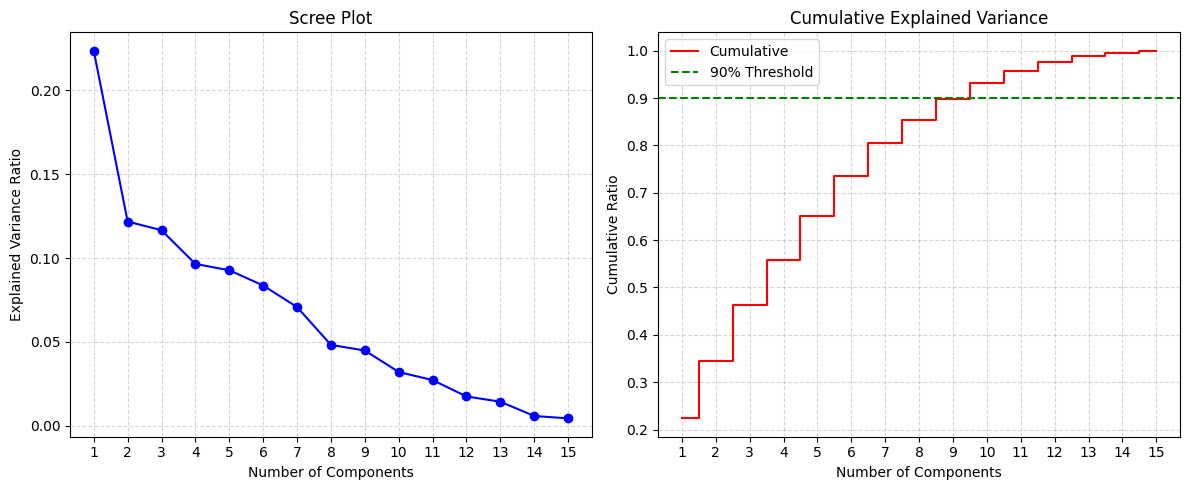

데이터의 90% 이상의 정보를 유지하기 위해 필요한 주성분 개수: 10개


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# 1. 모든 특성에 대해 PCA 수행
pca_full = PCA()
pca_full.fit(X_scaled_df)

# 2. 설명 분산 비율 및 누적 비율 계산
exp_var_ratio = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var_ratio)

# 3. 시각화 (Scree Plot & Cumulative Variance)
plt.figure(figsize=(12, 5))

# Scree Plot: 개별 주성분의 설명력
plt.subplot(1, 2, 1)
plt.plot(range(1, len(exp_var_ratio) + 1), exp_var_ratio, 'o-', color='blue')
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(exp_var_ratio) + 1))
plt.grid(True, linestyle='--', alpha=0.5)

# Cumulative Variance Plot: 누적 설명력
plt.subplot(1, 2, 2)
plt.step(range(1, len(cum_exp_var) + 1), cum_exp_var, where='mid', label='Cumulative', color='red')
plt.axhline(y=0.9, color='green', linestyle='--', label='90% Threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Ratio')
plt.xticks(range(1, len(cum_exp_var) + 1))
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 90% 분산을 설명하기 위한 최소 차원 수 확인
n_components_90 = np.where(cum_exp_var >= 0.9)[0][0] + 1
print(f"데이터의 90% 이상의 정보를 유지하기 위해 필요한 주성분 개수: {n_components_90}개")

In [9]:
from sklearn.decomposition import PCA

# PCA 수행 (2개 주성분 기준)
pca = PCA(n_components=9)
pca.fit(X_scaled_df)

# 각 주성분이 설명하는 분산 비율(Explained Variance Ratio) 계산
evr = pca.explained_variance_ratio_

print("=== PCA 주성별 설명 분산 비율 ===")
print(f"제1주성분 (PC1): {evr[0]:.2%}")
print(f"제2주성분 (PC2): {evr[1]:.2%}")
print(f"누적 설명 분산: {sum(evr):.2%}")

=== PCA 주성별 설명 분산 비율 ===
제1주성분 (PC1): 22.37%
제2주성분 (PC2): 12.18%
누적 설명 분산: 89.88%


### 클러스터링 시각화 

##### K-Means 클러스터링 시각화

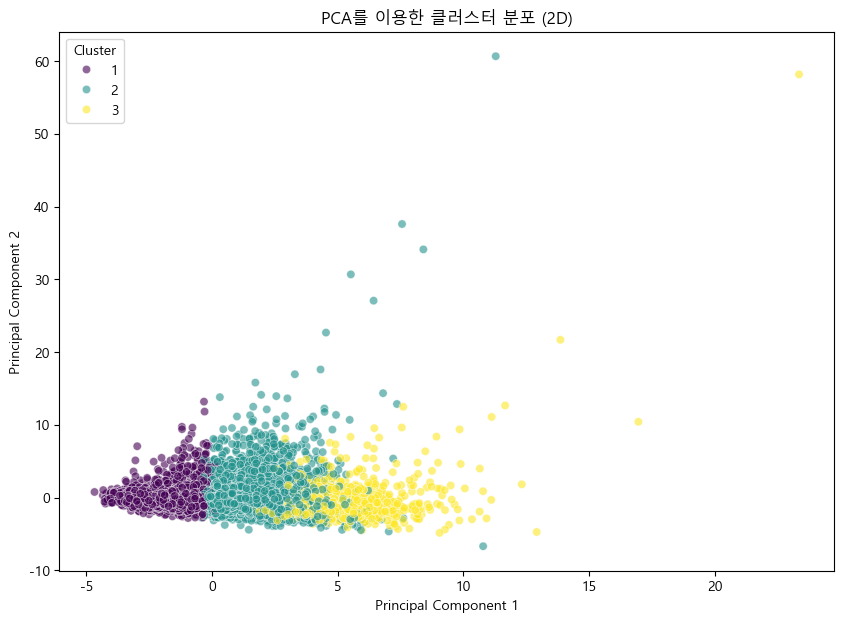

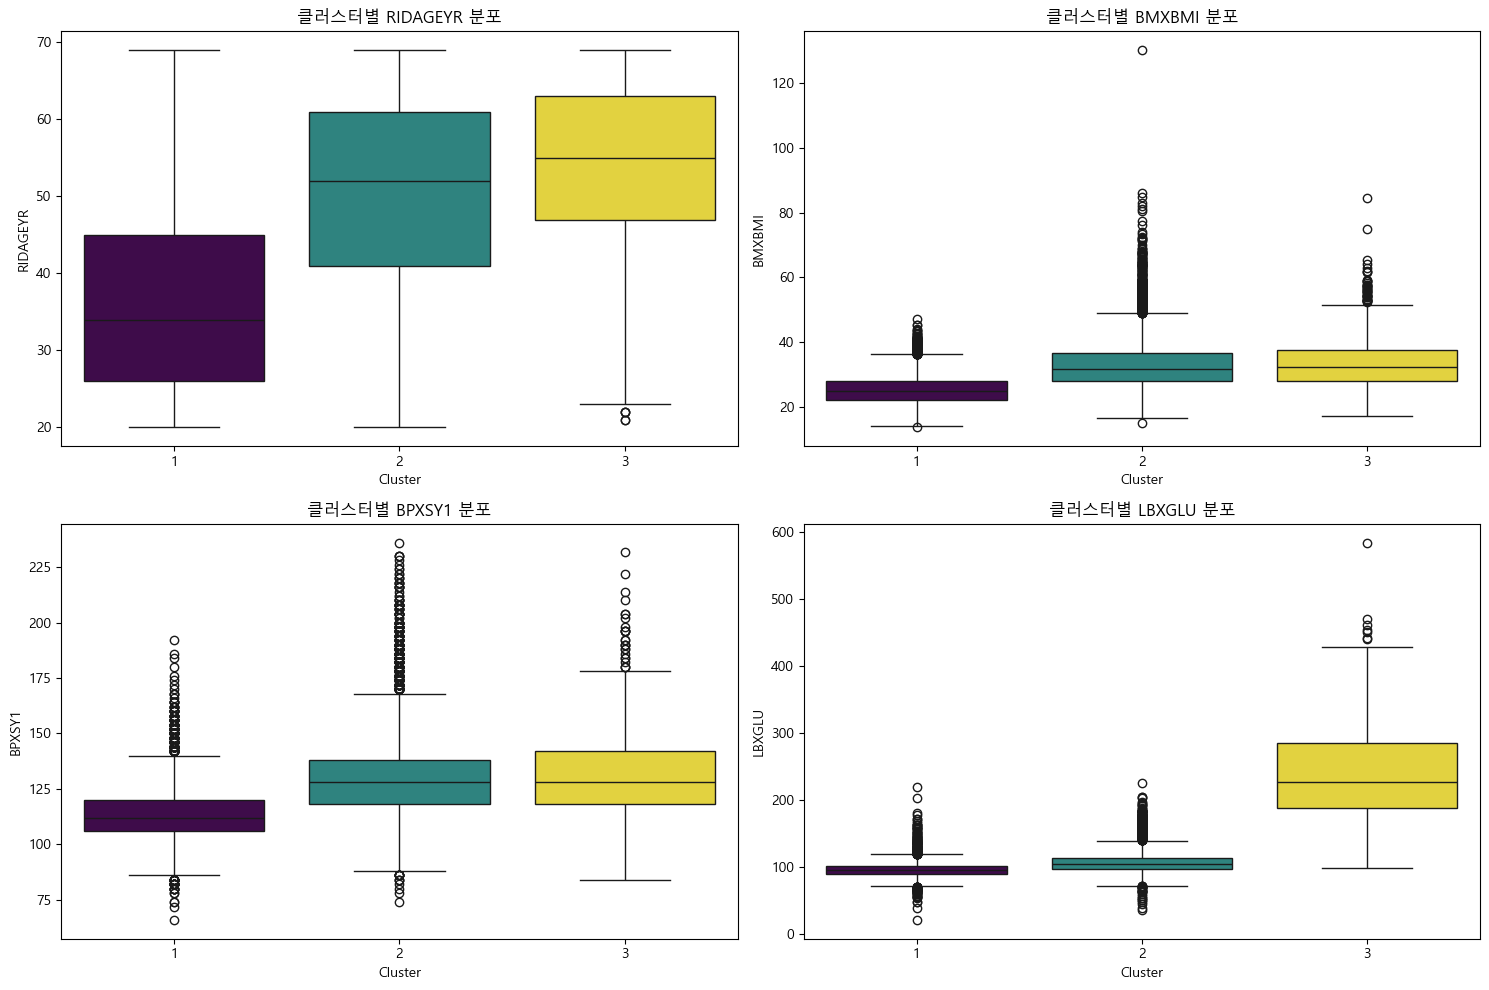

,RIDAGEYR,BMXBMI,BMXWAIST,BPXSY1,BPXDI1,LBXGLU,LBXGH,LBXSATSI,LBXSASSI,LBXSCR,LBXSBU,LBXSAL,LBDHDD,LBXTR,LBXTC
Cluster,,,,,,,,,,,,,,,
1,36.71,25.24,87.84,113.36,66.77,95.45,5.28,21.07,23.29,0.81,11.53,4.29,58.84,91.52,184.89
2,50.38,32.99,108.65,129.95,76.22,107.98,5.74,30.03,27.45,0.92,13.63,4.18,47.64,155.05,202.72
3,53.78,33.58,111.35,131.33,72.36,241.55,9.70,32.15,28.29,0.97,15.64,4.05,44.24,243.11,202.91


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 한글 폰트 설정 (Windows 기준)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. PCA를 이용한 2차원 시각화
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=merged_df["Cluster"], 
    palette="viridis", 
    alpha=0.6
)
plt.title("PCA를 이용한 클러스터 분포 (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

# 2. 클러스터별 주요 특성 비교 (Boxplot)
features_to_plot = ["RIDAGEYR", "BMXBMI", "BPXSY1", "LBXGLU"]
plt.figure(figsize=(15, 10))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
        x="Cluster",
        y=feature,
        hue="Cluster",
        data=merged_df,
        palette="viridis",
        legend=False,
    )
    plt.title(f"클러스터별 {feature} 분포")

plt.tight_layout()
plt.show()

# 3. 클러스터별 특성 평균값 확인
cluster_profile = merged_df.groupby("Cluster")[available_features].mean().round(2)
display(cluster_profile)

##### DBSCAN 클러스터링 시각화

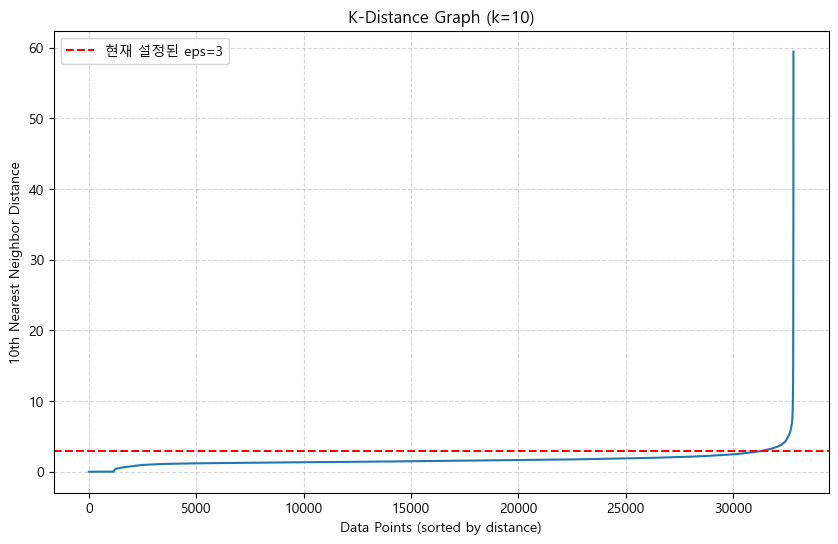

그래프에서 곡선이 급격하게 꺾이는 'Elbow' 지점의 y축 값이 최적의 eps 후보입니다.
현재 그래프를 보고 빨간 점선(eps=3)이 적절한 위치에 있는지 확인해 보세요.


In [11]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# 1. K-거리 그래프를 위한 거리 계산
# min_samples 값에 맞게 k를 설정합니다. (일반적으로 min_samples와 동일하거나 +1)
k = 10
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(X_scaled_df)
distances, indices = nbrs.kneighbors(X_scaled_df)

# k번째 가까운 이웃과의 거리만 추출하여 정렬
k_distances = np.sort(distances[:, k-1])

# 2. 시각화
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.axhline(y=3, color='r', linestyle='--', label='현재 설정된 eps=3') # 현재 사용 중인 eps 표시
plt.title(f"K-Distance Graph (k={k})")
plt.xlabel("Data Points (sorted by distance)")
plt.ylabel(f"{k}th Nearest Neighbor Distance")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("그래프에서 곡선이 급격하게 꺾이는 'Elbow' 지점의 y축 값이 최적의 eps 후보입니다.")
print("현재 그래프를 보고 빨간 점선(eps=3)이 적절한 위치에 있는지 확인해 보세요.")

In [12]:
# from sklearn.cluster import DBSCAN

# # 1. DBSCAN 클러스터링 수행
# # eps(반경)와 min_samples(최소 샘플 수)는 데이터에 따라 튜닝이 필요합니다.
# dbscan = DBSCAN(eps=2.5, min_samples=10)
# dbscan_labels = dbscan.fit_predict(X_scaled_df)

# # 2. PCA 결과(X_pca)를 재사용하여 시각화
# plt.figure(figsize=(10, 7))
# sns.scatterplot(
#     x=X_pca[:, 0], 
#     y=X_pca[:, 1], 
#     hue=dbscan_labels, 
#     palette="deep", 
#     alpha=0.6
# )
# plt.title("DBSCAN을 이용한 클러스터 분포 (2D)")
# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.legend(title="Cluster (-1: Noise)")
# plt.show()

# # 3. DBSCAN 결과 요약 출력
# n_clusters_ = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
# n_noise_ = list(dbscan_labels).count(-1)

# print(f"추정된 클러스터 수: {n_clusters_}")
# print(f"추정된 노이즈 포인트 수: {n_noise_} (전체의 {n_noise_/len(dbscan_labels)*100:.2f}%)")

# # 클러스터별 샘플 수 확인
# label_counts = pd.Series(dbscan_labels).value_counts().sort_index()
# print("\n클러스터별 샘플 수:")
# print(label_counts)

### 질병 이력 비교

##### K-Means 클러스터 유병률 비교

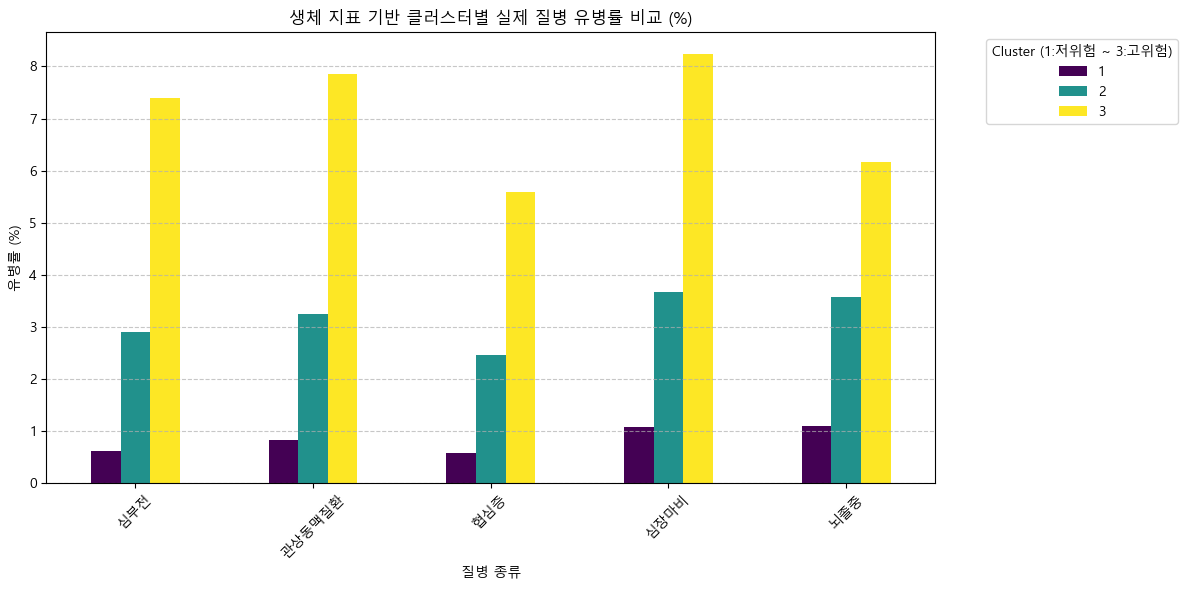

=== 클러스터별 질병 유병률 상세 (%) ===


,심부전,관상동맥질환,협심증,심장마비,뇌졸중
Cluster,,,,,
1,0.62,0.84,0.59,1.08,1.11
2,2.90,3.25,2.47,3.67,3.58
3,7.39,7.85,5.60,8.24,6.16



[분석 결과] 질병 유병률이 가장 높은 클러스터는 3번입니다.
생체 지표(혈압, 혈당 등)로 나눈 군집이 실제 의사 진단 이력과 일치하는지 확인하십시오.


In [13]:
# 1. MCQ (Medical Conditions) 데이터 로드 및 전처리
MCQ_COLUMNS = ["SEQN", "MCQ160B", "MCQ160C", "MCQ160D", "MCQ160E", "MCQ160F"]
mcq_frames = []

for suffix in CYCLE_SUFFIXES:
    file_key = f"MCQ_{suffix}"
    df_mcq = load_xpt(file_key, MCQ_COLUMNS)
    if not df_mcq.empty:
        mcq_frames.append(df_mcq)

mcq_df_all = pd.concat(mcq_frames, ignore_index=True)

# 2. 질병 유무 변환 (1: Yes -> 1, 2: No -> 0, 나머지는 NaN 처리)
disease_cols = [c for c in MCQ_COLUMNS if c != "SEQN"]
for col in disease_cols:
    # NHANES 기준: 1=Yes, 2=No, 7=Refused, 9=Don't know
    mcq_df_all[col] = mcq_df_all[col].map({1: 1, 2: 0})

# 3. 기존 merged_df(생체 지표 기반 클러스터링 결과)와 질병 데이터 병합
validation_df = merged_df[["SEQN", "Cluster"]].merge(mcq_df_all, on="SEQN", how="left")

# 4. 클러스터별 질병 유병률 계산
disease_names = {
    "MCQ160B": "심부전",
    "MCQ160C": "관상동맥질환",
    "MCQ160D": "협심증",
    "MCQ160E": "심장마비",
    "MCQ160F": "뇌졸중"
}

# 유병률(%) 계산 (해당 응답자 중 '예'라고 답한 비율)
cluster_disease_rate = validation_df.groupby("Cluster")[disease_cols].mean() * 100
cluster_disease_rate.columns = [disease_names.get(c, c) for c in cluster_disease_rate.columns]

# 5. 시각화
plt.figure(figsize=(12, 6))
cluster_disease_rate.T.plot(kind='bar', ax=plt.gca(), cmap='viridis')
plt.title("생체 지표 기반 클러스터별 실제 질병 유병률 비교 (%)")
plt.ylabel("유병률 (%)")
plt.xlabel("질병 종류")
plt.xticks(rotation=45)
plt.legend(title="Cluster (1:저위험 ~ 3:고위험)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 상세 수치 출력
print("=== 클러스터별 질병 유병률 상세 (%) ===")
display(cluster_disease_rate.round(2))

# 결론 도출 (간이 분석)
highest_risk_cluster = cluster_disease_rate.sum(axis=1).idxmax()
print(f"\n[분석 결과] 질병 유병률이 가장 높은 클러스터는 {highest_risk_cluster}번입니다.")
print("생체 지표(혈압, 혈당 등)로 나눈 군집이 실제 의사 진단 이력과 일치하는지 확인하십시오.")

In [14]:
# 전체 평균 유병률 계산 (클러스터 무관)
overall_rate = validation_df[disease_cols].mean(skipna=True) * 100
overall_rate.index = [disease_names.get(c, c) for c in overall_rate.index]

print("=== 전체 평균 유병률 (%) ===")
display(overall_rate.round(2))

# 클러스터별 유병률 표에 'Overall' 행 추가하여 함께 보기
cluster_with_overall = cluster_disease_rate.copy()
cluster_with_overall.loc['Overall'] = overall_rate.values
print("=== 클러스터별 유병률 + 전체 평균 (%) ===")
display(cluster_with_overall.round(2))

=== 전체 평균 유병률 (%) ===


심부전       2.01
관상동맥질환    2.30
협심증       1.71
심장마비      2.63
뇌졸중       2.52
dtype: float64

=== 클러스터별 유병률 + 전체 평균 (%) ===


,심부전,관상동맥질환,협심증,심장마비,뇌졸중
Cluster,,,,,
1,0.62,0.84,0.59,1.08,1.11
2,2.90,3.25,2.47,3.67,3.58
3,7.39,7.85,5.60,8.24,6.16
Overall,2.01,2.30,1.71,2.63,2.52


In [15]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy import stats

if "validation_df" not in globals() or "disease_cols" not in globals():
    raise ValueError("먼저 21번째 셀(유병률 계산 셀)을 실행하세요.")

clusters = sorted(validation_df["Cluster"].dropna().unique())
if len(clusters) < 2:
    raise ValueError("통계 검정을 위해 최소 2개 이상의 클러스터가 필요합니다.")

def benjamini_hochberg(p_values: list[float]) -> np.ndarray:
    p = np.array(p_values, dtype=float)
    n = len(p)
    if n == 0:
        return p
    order = np.argsort(p)
    ranked = p[order]
    adjusted = ranked * n / (np.arange(1, n + 1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out

def bootstrap_diff_ci(
    s1: pd.Series,
    s2: pd.Series,
    n_boot: int = 5000,
    ci: float = 0.95,
    random_state: int = 42,
 ):
    x = s1.dropna().to_numpy(dtype=float)
    y = s2.dropna().to_numpy(dtype=float)
    if len(x) < 2 or len(y) < 2:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(random_state)
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        diffs[i] = xb.mean() - yb.mean()

    alpha = 1 - ci
    lower = np.quantile(diffs, alpha / 2)
    upper = np.quantile(diffs, 1 - alpha / 2)
    p_boot = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    return lower, upper, p_boot

def cramers_v(contingency: pd.DataFrame) -> float:
    chi2, _, _, _ = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    denom = n * min(r - 1, k - 1)
    if denom <= 0:
        return np.nan
    return np.sqrt(chi2 / denom)

# 1) 쌍별 Welch t-test
ttest_rows = []
for disease in disease_cols:
    disease_name = disease_names.get(disease, disease) if "disease_names" in globals() else disease
    for c1, c2 in combinations(clusters, 2):
        s1 = validation_df.loc[validation_df["Cluster"] == c1, disease].dropna()
        s2 = validation_df.loc[validation_df["Cluster"] == c2, disease].dropna()
        if len(s1) < 2 or len(s2) < 2:
            continue

        t_stat, p_val = stats.ttest_ind(s1, s2, equal_var=False)
        p1, p2 = s1.mean(), s2.mean()
        diff_pct = (p1 - p2) * 100

        p1c = np.clip(p1, 1e-6, 1 - 1e-6)
        p2c = np.clip(p2, 1e-6, 1 - 1e-6)
        cohens_h = 2 * (np.arcsin(np.sqrt(p1c)) - np.arcsin(np.sqrt(p2c)))

        ttest_rows.append({
            "질병": disease_name,
            "비교": f"C{int(c1)} vs C{int(c2)}",
            "C1 유병률(%)": p1 * 100,
            "C2 유병률(%)": p2 * 100,
            "차이(%p)": diff_pct,
            "t_stat": t_stat,
            "p_value": p_val,
            "Cohen_h": cohens_h,
            "n1": len(s1),
            "n2": len(s2),
        })

ttest_df = pd.DataFrame(ttest_rows)
if not ttest_df.empty:
    ttest_df["p_fdr_bh"] = benjamini_hochberg(ttest_df["p_value"].tolist())
    ttest_df["유의(FDR<0.05)"] = ttest_df["p_fdr_bh"] < 0.05
    ttest_df = ttest_df.sort_values(["p_fdr_bh", "p_value"]).reset_index(drop=True)
    print("=== 쌍별 Welch t-test 결과 (FDR 보정) ===")
    display(ttest_df.round(4))
else:
    print("[INFO] t-test 가능한 비교가 없습니다.")

# 2) 부트스트래핑 (유병률 차이 95% CI)
boot_rows = []
for disease in disease_cols:
    disease_name = disease_names.get(disease, disease) if "disease_names" in globals() else disease
    for c1, c2 in combinations(clusters, 2):
        s1 = validation_df.loc[validation_df["Cluster"] == c1, disease]
        s2 = validation_df.loc[validation_df["Cluster"] == c2, disease]

        lower, upper, p_boot = bootstrap_diff_ci(s1, s2, n_boot=5000, ci=0.95, random_state=42)
        if np.isnan(lower):
            continue

        obs_diff = (s1.mean() - s2.mean()) * 100
        boot_rows.append({
            "질병": disease_name,
            "비교": f"C{int(c1)} vs C{int(c2)}",
            "관측 차이(%p)": obs_diff,
            "CI 하한(%p)": lower * 100,
            "CI 상한(%p)": upper * 100,
            "p_boot": p_boot,
            "유의(CI에 0 미포함)": not (lower <= 0 <= upper),
        })

boot_df = pd.DataFrame(boot_rows)
if not boot_df.empty:
    boot_df["p_fdr_bh"] = benjamini_hochberg(boot_df["p_boot"].tolist())
    boot_df["유의(FDR<0.05)"] = boot_df["p_fdr_bh"] < 0.05
    boot_df = boot_df.sort_values(["p_fdr_bh", "p_boot"]).reset_index(drop=True)
    print("\n=== 부트스트래핑 결과 (95% CI, FDR 보정) ===")
    display(boot_df.round(4))
else:
    print("[INFO] 부트스트랩 가능한 비교가 없습니다.")

# 3) 추가 분석: 질병별 카이제곱 + Cramér's V
chi_rows = []
for disease in disease_cols:
    disease_name = disease_names.get(disease, disease) if "disease_names" in globals() else disease
    temp = validation_df[["Cluster", disease]].dropna()
    if temp.empty:
        continue

    table = pd.crosstab(temp["Cluster"], temp[disease])
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue

    chi2, p_val, dof, _ = stats.chi2_contingency(table)
    chi_rows.append({
        "질병": disease_name,
        "chi2": chi2,
        "dof": dof,
        "p_value": p_val,
        "Cramers_V": cramers_v(table),
        "n": int(table.to_numpy().sum()),
    })

chi_df = pd.DataFrame(chi_rows)
if not chi_df.empty:
    chi_df["p_fdr_bh"] = benjamini_hochberg(chi_df["p_value"].tolist())
    chi_df["유의(FDR<0.05)"] = chi_df["p_fdr_bh"] < 0.05
    chi_df = chi_df.sort_values(["p_fdr_bh", "p_value"]).reset_index(drop=True)
    print("\n=== 카이제곱 검정 + Cramér'    s V (질병별 전체 비교) ===")
    display(chi_df.round(4))
else:
    print("[INFO] 카이제곱 검정 가능한 질병이 없습니다.")

=== 쌍별 Welch t-test 결과 (FDR 보정) ===


,질병,비교,C1 유병률(%),C2 유병률(%),차이(%p),t_stat,p_value,Cohen_h,n1,n2,p_fdr_bh,유의(FDR<0.05)
0,심부전,C1 vs C2,0.6238,2.8981,-2.2743,-15.4195,0.0000,-0.1840,15551,15838,0.0000,True
1,관상동맥질환,C1 vs C2,0.8362,3.2541,-2.4180,-15.2233,0.0000,-0.1796,15547,15826,0.0000,True
2,심장마비,C1 vs C2,1.0806,3.6654,-2.5848,-15.1384,0.0000,-0.1770,15547,15851,0.0000,True
3,뇌졸중,C1 vs C2,1.1123,3.5829,-2.4707,-14.5423,0.0000,-0.1695,15554,15853,0.0000,True
4,협심증,C1 vs C2,0.5855,2.4698,-1.8843,-13.6839,0.0000,-0.1624,15542,15831,0.0000,True
5,심장마비,C1 vs C3,1.0806,8.2430,-7.1624,-9.6214,0.0000,-0.3741,15547,1383,0.0000,True
6,관상동맥질환,C1 vs C3,0.8362,7.8545,-7.0184,-9.6215,0.0000,-0.3850,15547,1375,0.0000,True
7,심부전,C1 vs C3,0.6238,7.3913,-6.7676,-9.5673,0.0000,-0.3925,15551,1380,0.0000,True
8,협심증,C1 vs C3,0.5855,5.5959,-5.0104,-8.0443,0.0000,-0.3245,15542,1376,0.0000,True
9,뇌졸중,C1 vs C3,1.1123,6.1594,-5.0472,-7.7309,0.0000,-0.2903,15554,1380,0.0000,True



=== 부트스트래핑 결과 (95% CI, FDR 보정) ===


,질병,비교,관측 차이(%p),CI 하한(%p),CI 상한(%p),p_boot,유의(CI에 0 미포함),p_fdr_bh,유의(FDR<0.05)
0,심부전,C1 vs C2,-2.2743,-2.5645,-1.9893,0.0,True,0.0,True
1,심부전,C1 vs C3,-6.7676,-8.1976,-5.4052,0.0,True,0.0,True
2,심부전,C2 vs C3,-4.4932,-5.9329,-3.0817,0.0,True,0.0,True
3,관상동맥질환,C1 vs C2,-2.4180,-2.7305,-2.1025,0.0,True,0.0,True
4,관상동맥질환,C1 vs C3,-7.0184,-8.4472,-5.6042,0.0,True,0.0,True
5,관상동맥질환,C2 vs C3,-4.6004,-6.0610,-3.2029,0.0,True,0.0,True
6,협심증,C1 vs C2,-1.8843,-2.1583,-1.6107,0.0,True,0.0,True
7,협심증,C1 vs C3,-5.0104,-6.2635,-3.8199,0.0,True,0.0,True
8,협심증,C2 vs C3,-3.1261,-4.3457,-1.9158,0.0,True,0.0,True
9,심장마비,C1 vs C2,-2.5848,-2.9260,-2.2597,0.0,True,0.0,True



=== 카이제곱 검정 + Cramér'    s V (질병별 전체 비교) ===


,질병,chi2,dof,p_value,Cramers_V,n,p_fdr_bh,유의(FDR<0.05)
0,심부전,418.4538,2,0.0,0.1130,32769,0.0,True
1,관상동맥질환,401.2650,2,0.0,0.1107,32748,0.0,True
2,심장마비,381.8769,2,0.0,0.1079,32781,0.0,True
3,협심증,295.4518,2,0.0,0.0950,32749,0.0,True
4,뇌졸중,272.8754,2,0.0,0.0912,32787,0.0,True


### 레이더 차트 시각화 

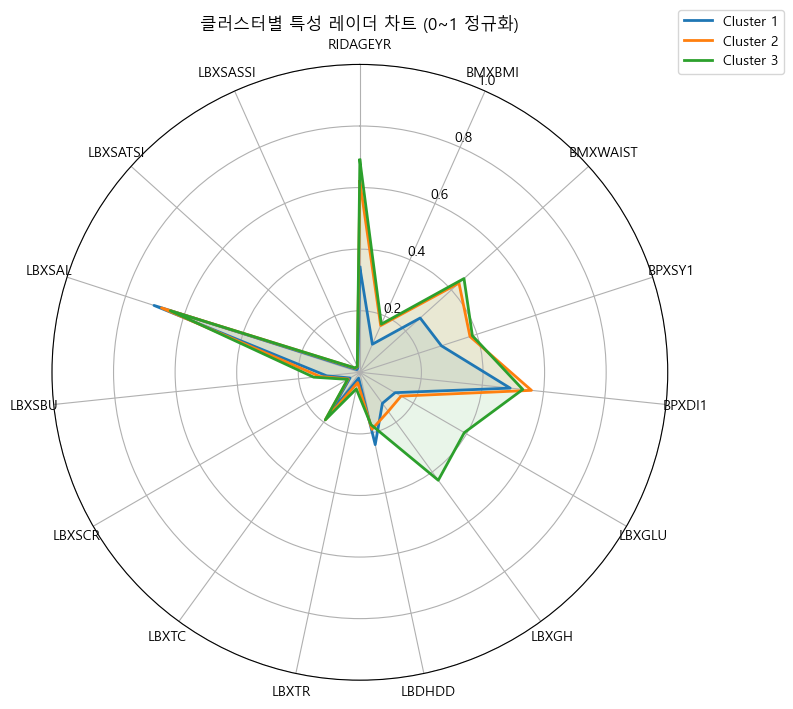

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 레이더 차트용으로 대표 특성 선택 (존재하는 컬럼만 사용)
radar_features = [
    "RIDAGEYR",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGLU",
    "LBXGH",
    "LBDHDD",
    "LBXTR",
    "LBXTC",
    "LBXSCR",
    "LBXSBU",
    "LBXSAL",
    "LBXSATSI",
    "LBXSASSI",
 ]
radar_features = [f for f in radar_features if f in merged_df.columns]
if len(radar_features) < 3:
    raise ValueError("레이더 차트에 사용할 특성 수가 부족합니다.")

# 전체 분포 기준으로 0~1 정규화
radar_scaler = MinMaxScaler()
scaled_all = radar_scaler.fit_transform(merged_df[radar_features])
scaled_all_df = merged_df[["Cluster"]].join(
    pd.DataFrame(scaled_all, columns=radar_features, index=merged_df.index)
 )

cluster_means = scaled_all_df.groupby("Cluster")[radar_features].mean().sort_index()

labels = radar_features
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
for cluster_id, row in cluster_means.iterrows():
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f"Cluster {cluster_id}")
    ax.fill(angles, values, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)
ax.set_title("클러스터별 특성 레이더 차트 (0~1 정규화)")
ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()

### 클러스터별 카이제곱 검정 / ANOVA 분석

In [17]:
import pandas as pd
from scipy import stats

# 1) 질병 유병률 차이: 카이제곱 검정
if "validation_df" not in globals():
    raise ValueError("validation_df가 없습니다. 질병 유병률 비교 셀을 먼저 실행하세요.")

chi_results = []
for col in disease_cols:
    table = pd.crosstab(validation_df["Cluster"], validation_df[col])
    if table.shape[1] < 2:
        continue
    chi2, p_value, dof, _ = stats.chi2_contingency(table)
    chi_results.append({"질병": col, "chi2": chi2, "p_value": p_value, "dof": dof})

chi_df = pd.DataFrame(chi_results).sort_values("p_value")
print("=== 카이제곱 검정 결과 (클러스터 간 유병률 차이) ===")
display(chi_df)

# 2) 생체 변수 차이: ANOVA
anova_features = [
    "RIDAGEYR",
    "BMXBMI",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBXGLU",
    "LBXGH",
    "LBDHDD",
    "LBXTR",
    "LBXTC",
    "LBXSCR",
    "LBXSBU",
    "LBXSAL",
    "LBXSATSI",
    "LBXSASSI",
 ]
anova_features = [f for f in anova_features if f in merged_df.columns]

anova_results = []
for feature in anova_features:
    groups = [
        merged_df.loc[merged_df["Cluster"] == c, feature].dropna()
        for c in sorted(merged_df["Cluster"].unique())
    ]
    if sum(len(g) > 0 for g in groups) < 2:
        continue
    f_stat, p_value = stats.f_oneway(*groups)
    anova_results.append({"특성": feature, "f_stat": f_stat, "p_value": p_value})

anova_df = pd.DataFrame(anova_results).sort_values("p_value")
print("=== ANOVA 결과 (클러스터 간 평균 차이) ===")
display(anova_df)

=== 카이제곱 검정 결과 (클러스터 간 유병률 차이) ===


,질병,chi2,p_value,dof
0,MCQ160B,418.453788,1.361176e-91,2
1,MCQ160C,401.264987,7.352162e-88,2
3,MCQ160E,381.876877,1.192586e-83,2
2,MCQ160D,295.451768,6.973707e-65,2
4,MCQ160F,272.875386,5.570098e-60,2


=== ANOVA 결과 (클러스터 간 평균 차이) ===


,특성,f_stat,p_value
0,RIDAGEYR,5132.629856,0.000000e+00
1,BMXBMI,6493.800756,0.000000e+00
2,BMXWAIST,9884.939797,0.000000e+00
3,BPXSY1,4322.868170,0.000000e+00
4,BPXDI1,2369.582162,0.000000e+00
5,LBXGLU,15247.973603,0.000000e+00
6,LBXGH,30217.613252,0.000000e+00
7,LBDHDD,2180.972958,0.000000e+00
8,LBXTR,959.367809,0.000000e+00
11,LBXSBU,865.358308,0.000000e+00


클러스터별 나이 통계:
              mean  median
Cluster                   
1        36.714882    34.0
2        50.377040    52.0
3        53.776895    55.0


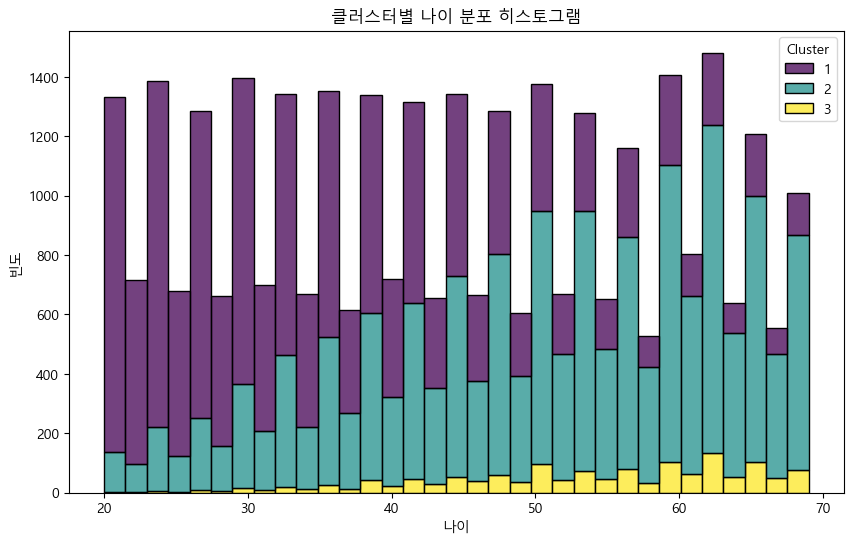

In [18]:
# 각 클러스터 별 평균 나이와 나이 중앙값 출력
cluster_age_stats = merged_df.groupby("Cluster")["RIDAGEYR"].agg(['mean', 'median'])
print("클러스터별 나이 통계:")
print(cluster_age_stats)

# 나이 히스토그램 출력
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=merged_df, x="RIDAGEYR", hue="Cluster", multiple="stack", palette="viridis")
plt.title("클러스터별 나이 분포 히스토그램")
plt.xlabel("나이")
plt.ylabel("빈도")
plt.show()

### GMM 클러스터링

In [19]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import pandas as pd

# merged_df 기반 GMM 클러스터링 + 실루엣 점수
gmm_features = [f for f in available_features if f in merged_df.columns]
if not gmm_features:
    raise ValueError("GMM에 사용할 특성이 없습니다.")

gmm_input = pd.DataFrame(
    imputer.transform(merged_df[gmm_features]),
    columns=gmm_features,
    index=merged_df.index,
)
gmmScaler = StandardScaler()
gmmInputScaledArray = gmmScaler.fit_transform(gmm_input[gmm_features])
gmm_input_scaled = pd.DataFrame(
    gmmInputScaledArray,
    columns=gmm_features,
    index=gmm_input.index,
)

gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=42)
gmm_labels = gmm.fit_predict(gmm_input_scaled)
gmm_silhouette = silhouette_score(gmm_input_scaled, gmm_labels)
print(f"GMM 실루엣 점수: {gmm_silhouette:.4f}")

GMM 실루엣 점수: 0.1284


### 모델 저장

In [20]:
import pickle
import joblib
from pathlib import Path

# 저장할 디렉토리 설정
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# 저장할 모델 딕셔너리
models_to_save = {
    "kmeans": kmeans,
    "imputer": imputer,
    "cluster_scaler": cluster_scaler,
    "label_map": label_map,
}

# pickle로 저장
for name, model in models_to_save.items():
    model_path = MODEL_DIR / f"{name}.pkl"
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    print(f"✓ 저장 완료: {model_path}")

print(f"\n모든 모델이 '{MODEL_DIR}' 디렉토리에 저장되었습니다.")


✓ 저장 완료: models\kmeans.pkl
✓ 저장 완료: models\imputer.pkl
✓ 저장 완료: models\cluster_scaler.pkl
✓ 저장 완료: models\label_map.pkl

모든 모델이 'models' 디렉토리에 저장되었습니다.


### 클러스터링 결과 csv 저장

In [21]:
# # K-Means 클러스터링 결과를 CSV로 저장
# from pathlib import Path

# if "merged_df" not in globals() or "Cluster" not in merged_df.columns:
#     raise ValueError("클러스터링 결과가 없습니다. K-Means 수행 셀을 먼저 실행하세요.")

# output_columns = [col for col in ["SEQN", "NHANES_CYCLE", "Cluster"] if col in merged_df.columns]
# if not output_columns:
#     raise ValueError("저장할 컬럼을 찾지 못했습니다.")

# cluster_result_df = merged_df[output_columns].copy()
# output_path = Path("cluster.csv")
# cluster_result_df.to_csv(output_path, index=False, encoding="utf-8-sig")

# print(f"저장 완료: {output_path.resolve()}")
# print(f"저장 행 수: {len(cluster_result_df)}")